# 🌱 Greenhouse Root-Zone pH & EC Soft-Sensor — v3
## Delta-Prediction GRU with Walk-Forward Validation

### Evolution
| Version | Validation | Target | pH R² | Key Issue |
|---|---|---|---|---|
| v1 | Temporal 80/20 | Absolute | -0.23 | Model never saw low-pH regime |
| v2 | Stratified split | Delta | (improved) | Temporal leakage; not deployment-realistic |
| **v3** | **Walk-forward** | **Delta** | **realistic** | Honest forward-in-time evaluation |

### Walk-Forward Scheme (Expanding Window)
```
Fold 1: ████████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░
         train (50 chunks)         val (12)

Fold 2: ████████████████████████████████████░░░░░░░░░░░░░░░░░░░░
         train (62 chunks)                  val (12)

Fold 3: ████████████████████████████████████████████████░░░░░░░░░
         train (74 chunks)                              val (12)

Fold 4: ████████████████████████████████████████████████████████░░
         train (86 chunks)                                    val (12)

Fold 5: ████████████████████████████████████████████████████████████
         train (98 chunks)                                        val (7)
```
No future data ever leaks into training. Each fold answers: **"if I deploy this model now, how will it perform over the next week?"**

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from copy import deepcopy
import matplotlib.pyplot as plt
import warnings, random

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


---
## 1 — Load Data

In [2]:
df = pd.read_csv('master.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df['soil_temp_pred'] = df['soil_temp_pred'].ffill().bfill()

FEATURE_COLS = [
    'ET0', 'internal_air_temp_c', 'internal_rh_%', 'internal_radiation',
    'irrigation_ml_current',
    'fertilization_flag', 'fertilization_type_a_flag', 'fertilization_type_b_flag',
    'soil_temp_pred', 'canopy_cover', 'days_after_planting',
    'Ammonium Nitrate [mg] -NH4NO3', 'Monopotassium Phosphate[mg] -KH2PO4',
    'Potassium Chloride[mg] - KCL', 'Phosphoric acid[mg]-H3PO4',
    'Kortin [mg]', 'Gypsum - CaSO4*2H2O [mg]',
]
TARGET_COLS = ['ec_ms', 'ph']
N_FEATURES = len(FEATURE_COLS)
N_TARGETS  = len(TARGET_COLS)

print(f'Shape: {df.shape} | Anchors: {df["ph"].notna().sum()} | Features: {N_FEATURES}')

Shape: (16682, 20) | Anchors: 109 | Features: 17


---
## 2 — Anchor-to-Anchor Chunking (Delta Formulation)

In [3]:
MAX_CHUNK_LEN = 720


def create_anchor_chunks(df, feature_cols, target_cols, max_chunk_len=None):
    """Slice DataFrame into variable-length anchor-to-anchor chunks with delta targets."""
    anchor_idx = df.index[df[target_cols[0]].notna()].tolist()
    chunks, dropped = [], 0

    for i in range(len(anchor_idx) - 1):
        a, b = anchor_idx[i], anchor_idx[i + 1]
        start = df.loc[a, target_cols].values.astype(np.float32)
        end   = df.loc[b, target_cols].values.astype(np.float32)

        if np.any(np.isnan(start)) or np.any(np.isnan(end)):
            continue

        feat = df.loc[a:b, feature_cols].values.astype(np.float32)
        seq_len = feat.shape[0]

        if seq_len < 2:
            continue
        if max_chunk_len and seq_len > max_chunk_len:
            dropped += 1
            continue

        chunks.append({
            'features': feat,
            'start_state': start,
            'end_target': end,
            'delta': end - start,
            'seq_len': seq_len,
            'anchor_a_idx': a,
            'anchor_b_idx': b,
            'timestamp_a': df.loc[a, 'timestamp'],
            'timestamp_b': df.loc[b, 'timestamp'],
        })

    return chunks, dropped


chunks, n_dropped = create_anchor_chunks(df, FEATURE_COLS, TARGET_COLS, MAX_CHUNK_LEN)
seq_lens = [c['seq_len'] for c in chunks]

print(f'Chunks: {len(chunks)} (dropped {n_dropped} exceeding {MAX_CHUNK_LEN} steps)')
print(f'Seq-len: min={min(seq_lens)}, max={max(seq_lens)}, mean={np.mean(seq_lens):.1f}')
print(f'Time span: {chunks[0]["timestamp_a"]} → {chunks[-1]["timestamp_b"]}')

Chunks: 105 (dropped 3 exceeding 720 steps)
Seq-len: min=3, max=570, mean=93.0
Time span: 2025-07-16 14:00:00 → 2025-09-21 15:30:00


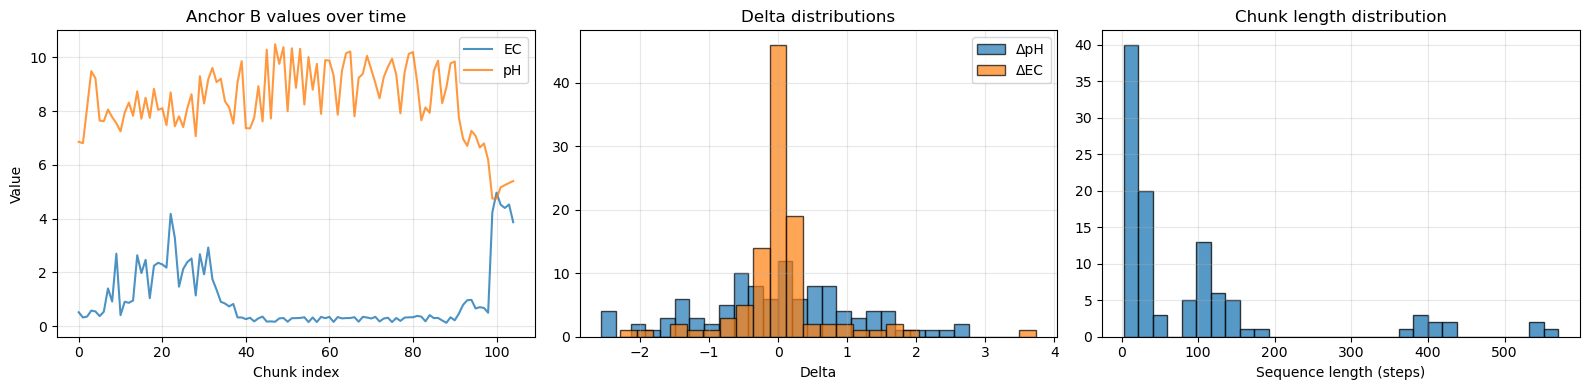

In [4]:
# ── Visualise anchor distribution and deltas ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

end_phs = [c['end_target'][1] for c in chunks]
end_ecs = [c['end_target'][0] for c in chunks]
delta_phs = [c['delta'][1] for c in chunks]
delta_ecs = [c['delta'][0] for c in chunks]

axes[0].plot(end_ecs, label='EC', alpha=0.8)
axes[0].plot(end_phs, label='pH', alpha=0.8)
axes[0].set_xlabel('Chunk index'); axes[0].set_ylabel('Value')
axes[0].set_title('Anchor B values over time'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(delta_phs, bins=25, alpha=0.7, edgecolor='k', label='ΔpH')
axes[1].hist(delta_ecs, bins=25, alpha=0.7, edgecolor='k', label='ΔEC')
axes[1].set_xlabel('Delta'); axes[1].set_title('Delta distributions')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].hist(seq_lens, bins=30, edgecolor='k', alpha=0.75)
axes[2].set_xlabel('Sequence length (steps)'); axes[2].set_title('Chunk length distribution')
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 3 — Scaling & Walk-Forward Fold Definitions

In [5]:
def fit_scalers(train_chunks):
    """Fit feature, target-state, and delta scalers on training chunks only."""
    feat_sc = RobustScaler().fit(np.vstack([c['features'] for c in train_chunks]))
    state_sc = StandardScaler().fit(np.vstack(
        [c['start_state'].reshape(1, -1) for c in train_chunks] +
        [c['end_target'].reshape(1, -1)  for c in train_chunks]
    ))
    delta_sc = StandardScaler().fit(
        np.vstack([c['delta'].reshape(1, -1) for c in train_chunks])
    )
    return feat_sc, state_sc, delta_sc


def scale_chunks(chunks, feat_sc, state_sc, delta_sc):
    """Scale and convert chunks to torch tensors."""
    scaled = []
    for c in chunks:
        scaled.append({
            'features':    torch.tensor(feat_sc.transform(c['features']).astype(np.float32)),
            'start_state': torch.tensor(state_sc.transform(c['start_state'].reshape(1,-1)).flatten().astype(np.float32)),
            'delta':       torch.tensor(delta_sc.transform(c['delta'].reshape(1,-1)).flatten().astype(np.float32)),
            'end_target':  c['end_target'],
            'start_raw':   c['start_state'],
            'seq_len':     c['seq_len'],
        })
    return scaled

In [6]:
# ── Define walk-forward folds ────────────────────────────────────
# Initial training window: ~50 chunks (~48% of data)
# Validation window: 12 chunks each (~1 week of anchors)
# Training window EXPANDS each fold (no data discarded)

MIN_TRAIN_SIZE = 50
VAL_WINDOW     = 12
N_CHUNKS       = len(chunks)

wf_folds = []
train_end = MIN_TRAIN_SIZE
while train_end < N_CHUNKS:
    val_end = min(train_end + VAL_WINDOW, N_CHUNKS)
    wf_folds.append({
        'train_slice': (0, train_end),
        'val_slice':   (train_end, val_end),
    })
    train_end = val_end

print(f'Walk-Forward Folds: {len(wf_folds)}')
print(f'{"="*75}')
for i, fold in enumerate(wf_folds):
    ts, te = fold['train_slice']
    vs, ve = fold['val_slice']
    val_c  = chunks[vs:ve]
    val_ph = [c['end_target'][1] for c in val_c]
    val_ec = [c['end_target'][0] for c in val_c]
    t_start = val_c[0]['timestamp_a']
    t_end   = val_c[-1]['timestamp_b']
    print(f'  Fold {i+1}: Train [{ts}:{te}] ({te-ts:>3d} chunks) │ '
          f'Val [{vs}:{ve}] ({ve-vs:>2d} chunks) │ '
          f'pH [{min(val_ph):.1f}–{max(val_ph):.1f}] │ '
          f'EC [{min(val_ec):.2f}–{max(val_ec):.2f}] │ '
          f'{t_start.date()} → {t_end.date()}')
print(f'{"="*75}')

Walk-Forward Folds: 5
  Fold 1: Train [0:50] ( 50 chunks) │ Val [50:62] (12 chunks) │ pH [7.9–10.3] │ EC [0.15–0.35] │ 2025-09-01 → 2025-09-09
  Fold 2: Train [0:62] ( 62 chunks) │ Val [62:74] (12 chunks) │ pH [7.8–10.2] │ EC [0.17–0.35] │ 2025-09-09 → 2025-09-14
  Fold 3: Train [0:74] ( 74 chunks) │ Val [74:86] (12 chunks) │ pH [7.7–10.2] │ EC [0.16–0.41] │ 2025-09-14 → 2025-09-16
  Fold 4: Train [0:86] ( 86 chunks) │ Val [86:98] (12 chunks) │ pH [6.7–9.9] │ EC [0.13–0.98] │ 2025-09-16 → 2025-09-18
  Fold 5: Train [0:98] ( 98 chunks) │ Val [98:105] ( 7 chunks) │ pH [4.8–6.2] │ EC [0.50–4.97] │ 2025-09-18 → 2025-09-21


---
## 4 — Model Definition

In [7]:
class DeltaGRUSoftSensor(nn.Module):
    """
    Many-to-One GRU predicting DELTA [EC, pH] from Anchor A to B.

    Architecture:
        features → GRU → final_hidden
        [final_hidden ∥ start_state] → MLP → Δ(EC, pH)

    Inference: predicted_B = start_A + inverse_scale(Δ)
    """

    def __init__(
        self,
        n_features: int  = 17,
        n_targets: int   = 2,
        hidden_size: int = 16,
        n_gru_layers: int = 2,
        mlp_hidden: int  = 24,
        dropout: float   = 0.25,
    ):
        super().__init__()
        self.n_features   = n_features
        self.n_targets    = n_targets
        self.hidden_size  = hidden_size
        self.n_gru_layers = n_gru_layers

        self.gru = nn.GRU(
            input_size=n_features, hidden_size=hidden_size,
            num_layers=n_gru_layers, batch_first=True,
            dropout=dropout if n_gru_layers > 1 else 0.0,
        )

        self.output_head = nn.Sequential(
            nn.Linear(hidden_size + n_targets, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, mlp_hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(mlp_hidden // 2, n_targets),
        )

    def forward(self, features, start_state, h0=None):
        _, h_final = self.gru(features, h0)
        final_hidden = h_final[-1]
        combined = torch.cat([final_hidden, start_state], dim=-1)
        delta_pred = self.output_head(combined)
        return delta_pred, h_final


# ── Hyperparameters ──────────────────────────────────────────────
HIDDEN_SIZE  = 16
N_GRU_LAYERS = 2
MLP_HIDDEN   = 24
DROPOUT      = 0.25

LEARNING_RATE  = 2e-3
WEIGHT_DECAY   = 3e-3
GRAD_CLIP_NORM = 1.0

# Print param count
_m = DeltaGRUSoftSensor(N_FEATURES, N_TARGETS, HIDDEN_SIZE, N_GRU_LAYERS, MLP_HIDDEN, DROPOUT)
print(_m)
print(f'\nTrainable params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m

DeltaGRUSoftSensor(
  (gru): GRU(17, 16, num_layers=2, batch_first=True, dropout=0.25)
  (output_head): Sequential(
    (0): Linear(in_features=18, out_features=24, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=24, out_features=12, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.125, inplace=False)
    (6): Linear(in_features=12, out_features=2, bias=True)
  )
)

Trainable params: 4,094


---
## 5 — Training & Evaluation Functions

In [8]:
def train_one_epoch(model, chunks, optimizer, criterion, device, grad_clip):
    """Train on delta targets, batch_size=1, shuffled."""
    model.train()
    total_loss = 0.0
    indices = list(range(len(chunks)))
    random.shuffle(indices)

    for i in indices:
        c = chunks[i]
        feat   = c['features'].unsqueeze(0).to(device)
        start  = c['start_state'].unsqueeze(0).to(device)
        target = c['delta'].unsqueeze(0).to(device)

        optimizer.zero_grad()
        pred, _ = model(feat, start)
        loss = criterion(pred, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(chunks)


@torch.no_grad()
def evaluate(model, chunks, criterion, device, delta_scaler):
    """Evaluate: loss on scaled deltas → original-scale absolute predictions."""
    model.eval()
    total_loss = 0.0
    preds_orig, targets_orig = [], []

    for c in chunks:
        feat   = c['features'].unsqueeze(0).to(device)
        start  = c['start_state'].unsqueeze(0).to(device)
        target = c['delta'].unsqueeze(0).to(device)

        pred_delta_s, _ = model(feat, start)
        total_loss += criterion(pred_delta_s, target).item()

        pred_delta = delta_scaler.inverse_transform(
            pred_delta_s.cpu().numpy().reshape(1, -1)
        ).flatten()
        pred_abs = c['start_raw'] + pred_delta
        preds_orig.append(pred_abs)
        targets_orig.append(c['end_target'])

    return total_loss / len(chunks), np.array(preds_orig), np.array(targets_orig)


def compute_metrics(preds, targets, target_cols):
    """Compute per-target MAE, RMSE, R²."""
    results = {}
    for i, name in enumerate(target_cols):
        p, t = preds[:, i], targets[:, i]
        results[name] = {
            'mae':  mean_absolute_error(t, p),
            'rmse': np.sqrt(mean_squared_error(t, p)),
            'r2':   r2_score(t, p) if len(t) > 1 else float('nan'),
        }
    return results

In [9]:
def train_fold(
    train_chunks_raw, val_chunks_raw,
    max_epochs=600, patience=50, verbose=True,
):
    """
    Train a fresh model on one walk-forward fold.

    Returns: best_model_state, scalers, train_losses, val_losses,
             val_preds, val_targets
    """
    # ── Fit scalers on this fold's training data ──────────────────
    feat_sc, state_sc, delta_sc = fit_scalers(train_chunks_raw)
    train_s = scale_chunks(train_chunks_raw, feat_sc, state_sc, delta_sc)
    val_s   = scale_chunks(val_chunks_raw,   feat_sc, state_sc, delta_sc)

    # ── Fresh model ──────────────────────────────────────────────
    model = DeltaGRUSoftSensor(
        n_features=N_FEATURES, n_targets=N_TARGETS,
        hidden_size=HIDDEN_SIZE, n_gru_layers=N_GRU_LAYERS,
        mlp_hidden=MLP_HIDDEN, dropout=DROPOUT,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=80, T_mult=2)
    criterion = nn.HuberLoss(delta=1.0)

    # ── Training loop ────────────────────────────────────────────
    train_losses, val_losses = [], []
    best_vl, best_ms, no_imp = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        tl = train_one_epoch(model, train_s, optimizer, criterion, DEVICE, GRAD_CLIP_NORM)
        vl, _, _ = evaluate(model, val_s, criterion, DEVICE, delta_sc)
        train_losses.append(tl); val_losses.append(vl)
        scheduler.step()

        if vl < best_vl:
            best_vl, best_ms, no_imp = vl, deepcopy(model.state_dict()), 0
        else:
            no_imp += 1

        if no_imp >= patience:
            if verbose:
                print(f'    Early stop at epoch {epoch} (best val loss: {best_vl:.6f})')
            break

    # ── Evaluate best model ──────────────────────────────────────
    model.load_state_dict(best_ms)
    _, preds, targets = evaluate(model, val_s, criterion, DEVICE, delta_sc)

    return {
        'model_state': best_ms,
        'scalers': (feat_sc, state_sc, delta_sc),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_preds': preds,
        'val_targets': targets,
        'best_val_loss': best_vl,
        'stopped_epoch': len(train_losses),
    }

---
## 6 — Run Walk-Forward Validation

In [10]:
WF_MAX_EPOCHS = 600
WF_PATIENCE   = 50

fold_results = []

print(f'Running {len(wf_folds)}-fold walk-forward validation')
print(f'Max epochs per fold: {WF_MAX_EPOCHS}, Patience: {WF_PATIENCE}')
print('=' * 75)

for i, fold in enumerate(wf_folds):
    ts, te = fold['train_slice']
    vs, ve = fold['val_slice']

    train_c = chunks[ts:te]
    val_c   = chunks[vs:ve]

    print(f'\nFold {i+1}/{len(wf_folds)}: Train [{ts}:{te}] ({te-ts} chunks) → '
          f'Val [{vs}:{ve}] ({ve-vs} chunks)')

    result = train_fold(
        train_c, val_c,
        max_epochs=WF_MAX_EPOCHS,
        patience=WF_PATIENCE,
        verbose=True,
    )

    metrics = compute_metrics(result['val_preds'], result['val_targets'], TARGET_COLS)
    result['metrics'] = metrics
    result['fold_idx'] = i
    result['val_chunks_raw'] = val_c
    fold_results.append(result)

    for name in TARGET_COLS:
        m = metrics[name]
        print(f'    {name:>6s}: MAE={m["mae"]:.4f}  RMSE={m["rmse"]:.4f}  R²={m["r2"]:.4f}')

print(f'\n{"="*75}')
print('Walk-forward validation complete.')

Running 5-fold walk-forward validation
Max epochs per fold: 600, Patience: 50

Fold 1/5: Train [0:50] (50 chunks) → Val [50:62] (12 chunks)
    Early stop at epoch 61 (best val loss: 0.170695)
     ec_ms: MAE=0.2697  RMSE=0.3138  R²=-15.4527
        ph: MAE=0.6937  RMSE=0.8218  R²=0.0704

Fold 2/5: Train [0:62] (62 chunks) → Val [62:74] (12 chunks)
    Early stop at epoch 57 (best val loss: 0.047158)
     ec_ms: MAE=0.1003  RMSE=0.1227  R²=-3.4753
        ph: MAE=0.4264  RMSE=0.4966  R²=0.5891

Fold 3/5: Train [0:74] (74 chunks) → Val [74:86] (12 chunks)
    Early stop at epoch 55 (best val loss: 0.039203)
     ec_ms: MAE=0.1157  RMSE=0.1456  R²=-2.5841
        ph: MAE=0.2980  RMSE=0.4050  R²=0.7901

Fold 4/5: Train [0:86] (86 chunks) → Val [86:98] (12 chunks)
    Early stop at epoch 52 (best val loss: 0.128597)
     ec_ms: MAE=0.1343  RMSE=0.1764  R²=0.6200
        ph: MAE=0.6622  RMSE=0.7916  R²=0.5916

Fold 5/5: Train [0:98] (98 chunks) → Val [98:105] (7 chunks)
    Early stop at ep

---
## 7 — Walk-Forward Results & Diagnostics

In [11]:
# ── Aggregate metrics across folds ───────────────────────────────
print('Walk-Forward Results by Fold')
print('=' * 80)
print(f'{"Fold":>5s} │ {"EC MAE":>8s} {"EC RMSE":>9s} {"EC R²":>8s} │ '
      f'{"pH MAE":>8s} {"pH RMSE":>9s} {"pH R²":>8s} │ {"Epochs":>6s}')
print('-' * 80)

for i, r in enumerate(fold_results):
    ec = r['metrics']['ec_ms']
    ph = r['metrics']['ph']
    print(f'{i+1:>5d} │ {ec["mae"]:>8.4f} {ec["rmse"]:>9.4f} {ec["r2"]:>8.4f} │ '
          f'{ph["mae"]:>8.4f} {ph["rmse"]:>9.4f} {ph["r2"]:>8.4f} │ {r["stopped_epoch"]:>6d}')

# Weighted average (by val size)
print('-' * 80)
for name in TARGET_COLS:
    all_preds  = np.vstack([r['val_preds'] for r in fold_results])
    all_targs  = np.vstack([r['val_targets'] for r in fold_results])
    idx = TARGET_COLS.index(name)
    p, t = all_preds[:, idx], all_targs[:, idx]
    print(f'  {name:>6s} POOLED │  MAE: {mean_absolute_error(t,p):.4f}  │  '
          f'RMSE: {np.sqrt(mean_squared_error(t,p)):.4f}  │  R²: {r2_score(t,p):.4f}')
print('=' * 80)

Walk-Forward Results by Fold
 Fold │   EC MAE   EC RMSE    EC R² │   pH MAE   pH RMSE    pH R² │ Epochs
--------------------------------------------------------------------------------
    1 │   0.2697    0.3138 -15.4527 │   0.6937    0.8218   0.0704 │     61
    2 │   0.1003    0.1227  -3.4753 │   0.4264    0.4966   0.5891 │     57
    3 │   0.1157    0.1456  -2.5841 │   0.2980    0.4050   0.7901 │     55
    4 │   0.1343    0.1764   0.6200 │   0.6622    0.7916   0.5916 │     52
    5 │   0.8216    1.4236  -0.0259 │   0.5537    0.7063  -1.4628 │     53
--------------------------------------------------------------------------------
   ec_ms POOLED │  MAE: 0.2398  │  RMSE: 0.5423  │  R²: 0.8219
      ph POOLED │  MAE: 0.5243  │  RMSE: 0.6612  │  R²: 0.8268


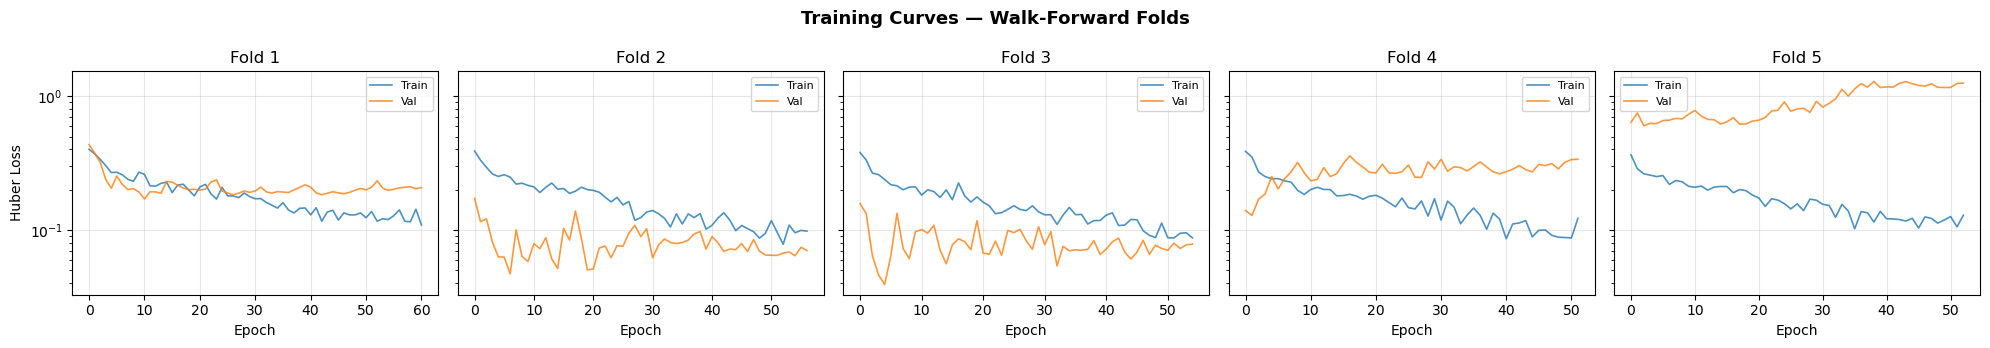

In [12]:
# ── Loss curves for each fold ────────────────────────────────────
fig, axes = plt.subplots(1, len(fold_results), figsize=(4*len(fold_results), 3.5), sharey=True)
if len(fold_results) == 1:
    axes = [axes]

for i, (ax, r) in enumerate(zip(axes, fold_results)):
    ax.plot(r['train_losses'], label='Train', alpha=0.8, lw=1.2)
    ax.plot(r['val_losses'],   label='Val',   alpha=0.8, lw=1.2)
    ax.set_xlabel('Epoch'); ax.set_title(f'Fold {i+1}')
    ax.set_yscale('log'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Huber Loss')
plt.suptitle('Training Curves — Walk-Forward Folds', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

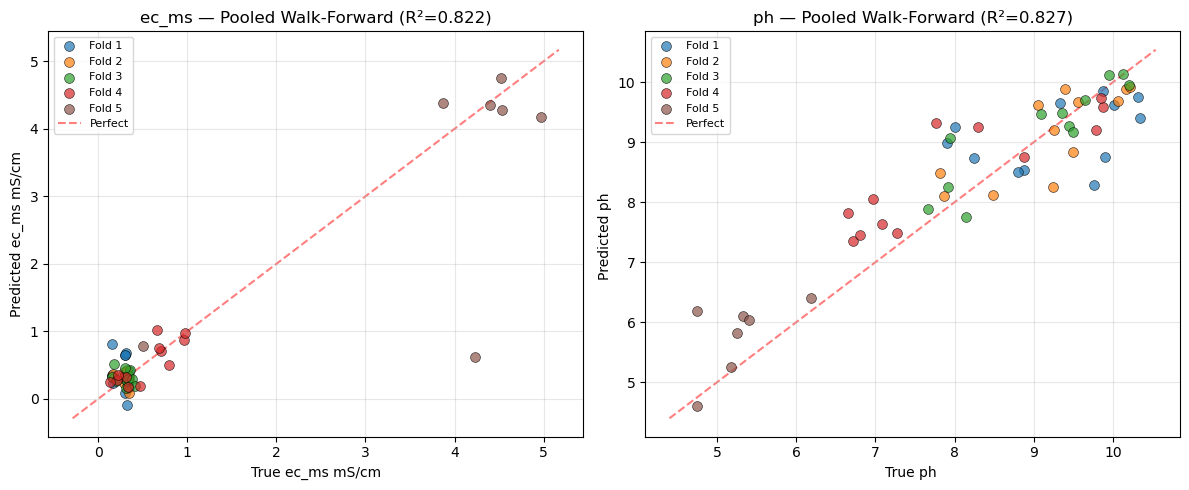

In [13]:
# ── Scatter plots: pooled predictions across all folds ───────────
all_preds  = np.vstack([r['val_preds'] for r in fold_results])
all_targs  = np.vstack([r['val_targets'] for r in fold_results])
all_folds  = np.concatenate([np.full(len(r['val_preds']), i)
                             for i, r in enumerate(fold_results)])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 0.5, len(fold_results)))

for idx, (name, unit) in enumerate(zip(TARGET_COLS, ['mS/cm', ''])):
    ax = axes[idx]
    for fi in range(len(fold_results)):
        mask = all_folds == fi
        ax.scatter(all_targs[mask, idx], all_preds[mask, idx],
                   alpha=0.7, s=50, edgecolors='k', lw=0.5,
                   color=colors[fi], label=f'Fold {fi+1}', zorder=3)

    lims = [min(all_targs[:, idx].min(), all_preds[:, idx].min()) - 0.2,
            max(all_targs[:, idx].max(), all_preds[:, idx].max()) + 0.2]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect', zorder=1)
    ax.set_xlabel(f'True {name} {unit}'); ax.set_ylabel(f'Predicted {name} {unit}')
    r2 = r2_score(all_targs[:, idx], all_preds[:, idx])
    ax.set_title(f'{name} — Pooled Walk-Forward (R²={r2:.3f})')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

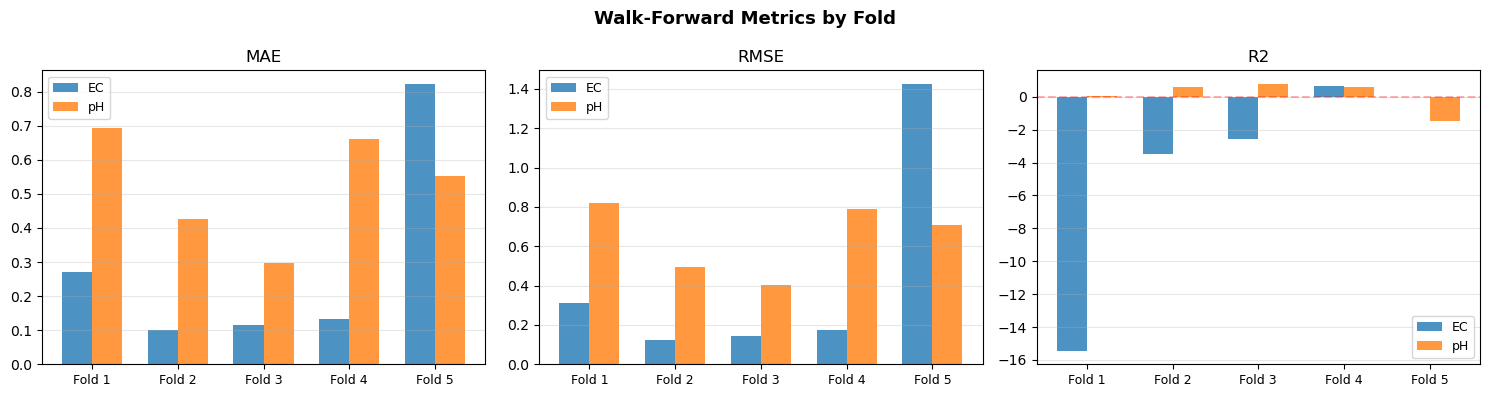

In [14]:
# ── Per-fold bar chart of metrics ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fold_labels = [f'Fold {i+1}' for i in range(len(fold_results))]
x = np.arange(len(fold_results))
width = 0.35

for ax_idx, metric_name in enumerate(['mae', 'rmse', 'r2']):
    ax = axes[ax_idx]
    ec_vals = [r['metrics']['ec_ms'][metric_name] for r in fold_results]
    ph_vals = [r['metrics']['ph'][metric_name] for r in fold_results]
    ax.bar(x - width/2, ec_vals, width, label='EC', alpha=0.8)
    ax.bar(x + width/2, ph_vals, width, label='pH', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(fold_labels, fontsize=9)
    ax.set_title(metric_name.upper()); ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    if metric_name == 'r2':
        ax.axhline(0, color='red', ls='--', alpha=0.3)

plt.suptitle('Walk-Forward Metrics by Fold', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()